# Prediction of Mohs Hardness with Machine Learning

#### Description
Hardness, or the quantitative value of resistance to permanent or plastic deformation, plays a very crucial role in materials design in many applications, such as ceramic coatings and abrasives. Hardness testing is an especially useful method as it is non-destructive and simple to implement to gauge the plastic properties of a material. In this study, I proposed a machine, or statistical, learning approach to predict hardness in naturally occurring materials, which integrates atomic and electronic features from composition directly across a wide variety of mineral compositions and crystal systems. First, atomic and electronic features from the composition, such as van der Waals and covalent radii as well as the number of valence electrons, were extracted from the composition.

In this study, the author trained a set of classifiers to understand whether compositional features can be used to predict the Mohs hardness of minerals of different chemical spaces, crystal structures, and crystal classes. The dataset used in this study originated from experimental Mohs hardness data, their crystal classes, and chemical compositions of naturally occurring minerals reported in the Physical and Optical Properties of Minerals CRC Handbook of Chemistry and Physics and the American Mineralogist Crystal Structure Database. The database is composed of 369 uniquely named minerals. Due to the presence of multiple composition combinations for minerals referred to by the same name, the first step was to perform compositional permutations on these minerals. This produced a database of 622 minerals of unique compositions, comprising 210 monoclinic, 96 rhombohedral, 89 hexagonal, 80 tetragonal, 73 cubic, 50 orthorhombic, 22 triclinic, 1 trigonal, and 1 amorphous structure.

In this study, the author constructed a database of compositional feature descriptors that characterize naturally occurring materials obtained directly from the Physical and Optical Properties of Minerals CRC Handbook45. This comprehensive compositional-based dataset allows us to train models that are able to predict hardness across a wide variety of mineral compositions and crystal classes. Each material in both the naturally occurring mineral and artificial single crystal datasets was represented by 11 atomic descriptors. The elemental features are the number of electrons, number of valence electrons, atomic number, Pauling electronegativity of the most common oxidation state, covalent atomic radii, van der Waals radii, and ionization energy of neutral.

#### Acknowledgements & Source
Joy Carleen Garnett, Ph.D.
Data Scientist at Louisiana-Pacific Corporation | Python | Azure | Databricks | Snowflake | Tableau | Data Pipelines

Vanderbilt University
Nashville, Tennessee, United States

## LIBRARIES AND DATA IMPORT

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest, GradientBoostingRegressor
from sklearn.metrics import median_absolute_error

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import keras
import tensorflow as tf
import tensorflow_probability as tfp

In [4]:
data = pd.read_csv('/content/drive/MyDrive/bootcamp batch9/hardness dataset/train.csv')
data

,id,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
0,0,100.0,0.841611,10.000000,4.800000,20.612526,11.088100,2.766000,1.732000,0.860000,0.496070,0.91457,6.0
1,1,100.0,7.558488,10.000000,4.800000,20.298893,12.040830,2.755000,1.631000,0.910000,0.492719,0.71760,6.5
2,2,76.0,8.885992,15.600000,5.600000,33.739258,12.086300,2.828000,1.788000,0.864000,0.481478,1.50633,2.5
3,3,100.0,8.795296,10.000000,4.800000,20.213349,10.948500,2.648000,1.626000,0.936000,0.489272,0.78937,6.0
4,4,116.0,9.577996,11.600000,4.800000,24.988133,11.824480,2.766000,1.682000,0.896000,0.492736,1.86481,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10402,10402,128.0,7.558488,12.000000,4.000000,26.385218,11.330440,2.644000,1.631000,0.892000,0.496070,1.79607,4.0
10403,10403,30.0,1.743160,10.000000,5.333333,20.766935,14.163933,3.090000,1.556667,0.866667,0.480390,0.81480,5.0
10404,10404,196.0,30.920000,24.500000,5.500000,53.490297,10.074300,2.295000,1.545000,1.120000,0.469715,2.11540,1.8
10405,10405,38.0,1.553160,12.666667,4.666667,26.621687,11.290033,2.743333,1.756667,0.980000,0.486507,0.77755,6.0


In [5]:
data.isnull().sum()

,0
id,0
allelectrons_Total,0
density_Total,0
allelectrons_Average,0
val_e_Average,0
atomicweight_Average,0
ionenergy_Average,0
el_neg_chi_Average,0
R_vdw_element_Average,0
R_cov_element_Average,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10407 entries, 0 to 10406
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     10407 non-null  int64  
 1   allelectrons_Total     10407 non-null  float64
 2   density_Total          10407 non-null  float64
 3   allelectrons_Average   10407 non-null  float64
 4   val_e_Average          10407 non-null  float64
 5   atomicweight_Average   10407 non-null  float64
 6   ionenergy_Average      10407 non-null  float64
 7   el_neg_chi_Average     10407 non-null  float64
 8   R_vdw_element_Average  10407 non-null  float64
 9   R_cov_element_Average  10407 non-null  float64
 10  zaratio_Average        10407 non-null  float64
 11  density_Average        10407 non-null  float64
 12  Hardness               10407 non-null  float64
dtypes: float64(12), int64(1)
memory usage: 1.0 MB


In [7]:
data.describe()

,id,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
count,10407.00000,10407.000000,10407.000000,10407.000000,10407.000000,10407.000000,10407.000000,10407.000000,10407.000000,10407.000000,10407.000000,10407.000000,10407.000000
mean,5203.00000,128.053516,14.491342,17.033222,4.546789,37.507703,10.938308,2.607662,1.731330,0.944132,0.493349,2.132984,4.647126
std,3004.38646,224.123776,15.972877,10.468734,0.690864,26.012313,1.408276,0.334906,0.192481,0.180017,0.063080,1.936656,1.680525
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2601.50000,68.000000,7.558488,10.000000,4.000000,20.298893,10.590660,2.530000,1.672500,0.864000,0.476196,0.814800,3.000000
50%,5203.00000,100.000000,10.650000,12.600000,4.714286,26.203827,11.202760,2.706000,1.732727,0.915556,0.488550,1.351550,5.500000
75%,7804.50000,131.000000,16.676996,22.000000,4.800000,48.719500,11.670725,2.805000,1.800000,0.981667,0.496070,2.741550,6.000000
max,10406.00000,15300.000000,643.093804,67.000000,6.000000,167.400000,15.245810,3.443000,2.250000,1.615840,0.825990,10.970000,10.000000


In [8]:
data = data.drop(columns='id')
data

,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
0,100.0,0.841611,10.000000,4.800000,20.612526,11.088100,2.766000,1.732000,0.860000,0.496070,0.91457,6.0
1,100.0,7.558488,10.000000,4.800000,20.298893,12.040830,2.755000,1.631000,0.910000,0.492719,0.71760,6.5
2,76.0,8.885992,15.600000,5.600000,33.739258,12.086300,2.828000,1.788000,0.864000,0.481478,1.50633,2.5
3,100.0,8.795296,10.000000,4.800000,20.213349,10.948500,2.648000,1.626000,0.936000,0.489272,0.78937,6.0
4,116.0,9.577996,11.600000,4.800000,24.988133,11.824480,2.766000,1.682000,0.896000,0.492736,1.86481,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10402,128.0,7.558488,12.000000,4.000000,26.385218,11.330440,2.644000,1.631000,0.892000,0.496070,1.79607,4.0
10403,30.0,1.743160,10.000000,5.333333,20.766935,14.163933,3.090000,1.556667,0.866667,0.480390,0.81480,5.0
10404,196.0,30.920000,24.500000,5.500000,53.490297,10.074300,2.295000,1.545000,1.120000,0.469715,2.11540,1.8
10405,38.0,1.553160,12.666667,4.666667,26.621687,11.290033,2.743333,1.756667,0.980000,0.486507,0.77755,6.0


REMARKS: The dataset consist of 10407 entries, and 13 features. We observed no NaN data, majority of features have float data type and no categorical features, and therefore we don't need to do encoding steps. We dropped the 'id' features because it's just unique values for naming each entries.

## EXPLORATORY DATA ANALYSIS: FEATURES OVERVIEW

We will first plot Pair Grid of all features in relation to target features so that we can see the distributions of each data.

/tmp/ipython-input-9-3227744347.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_a['hardness'] = data['Hardness']


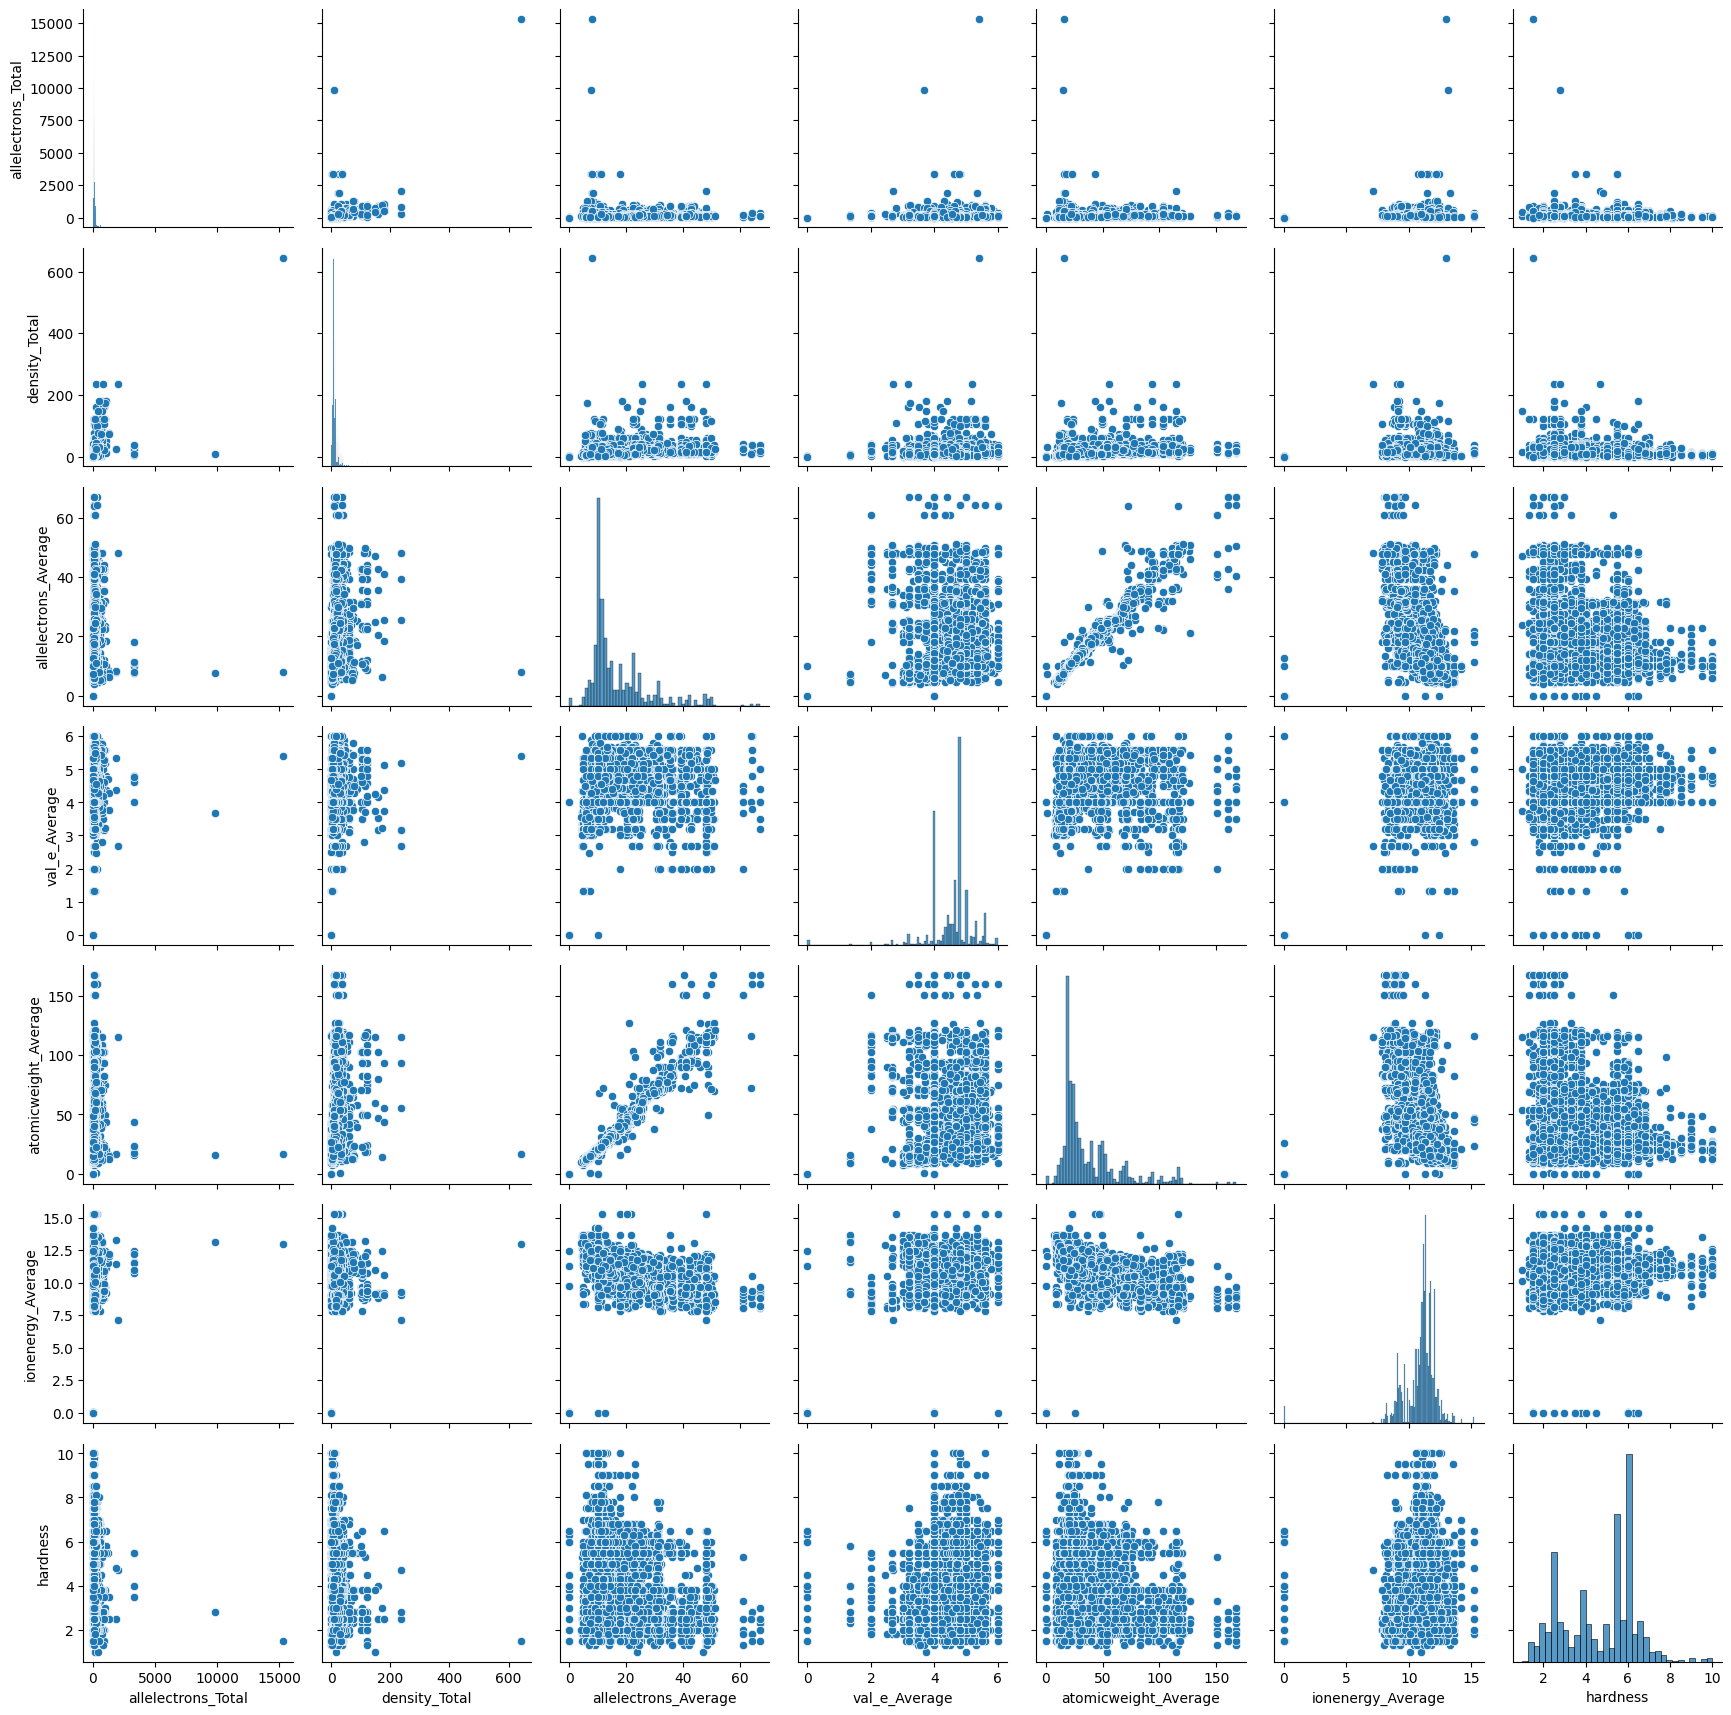

In [9]:
data_a = data.iloc[:, :6]
data_b = data.iloc[:, 6:]
data_a['hardness'] = data['Hardness']

pair_a = sns.PairGrid(data=data_a,diag_sharey=False)
pair_a.map_upper(sns.scatterplot)
pair_a.map_diag(sns.histplot)
pair_a.map_lower(sns.scatterplot)
pair_a


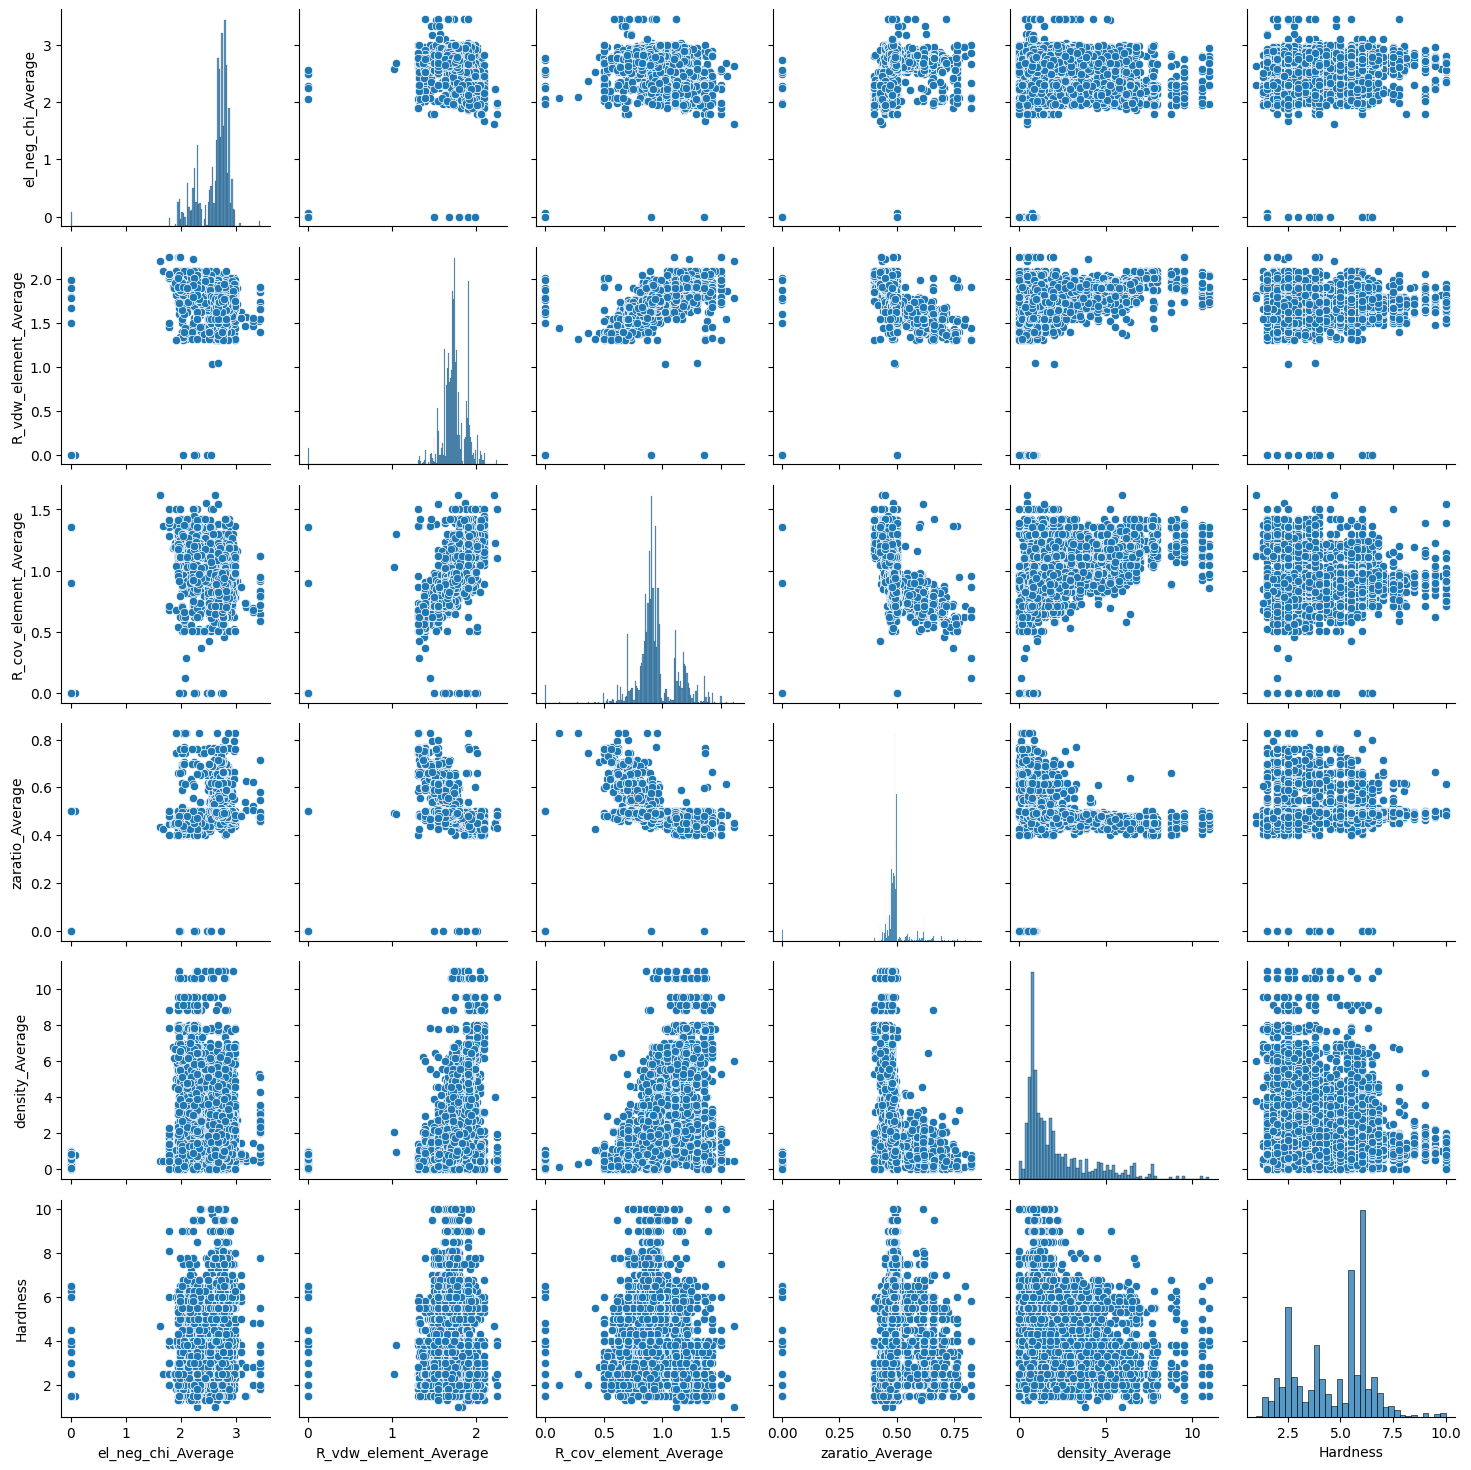

In [10]:
pair_b = sns.PairGrid(data=data_b,diag_sharey=False)
pair_b.map_upper(sns.scatterplot)
pair_b.map_diag(sns.histplot)
pair_b.map_lower(sns.scatterplot)
pair_b

REMARKS: From this Pair Grid we can see most of the data forms singular cluster in all features, and we can already see some outliers in the data (0 valued data). We shall see the density location and detailed distribution after this by using scatterplot and hexbin. We can also observed 2 features namely 'allelectrons_Total' and 'density_Total' are forming vertical structure which can make Machine Learning prediction difficult. Therefore, we shall apply log transformation on these features later.

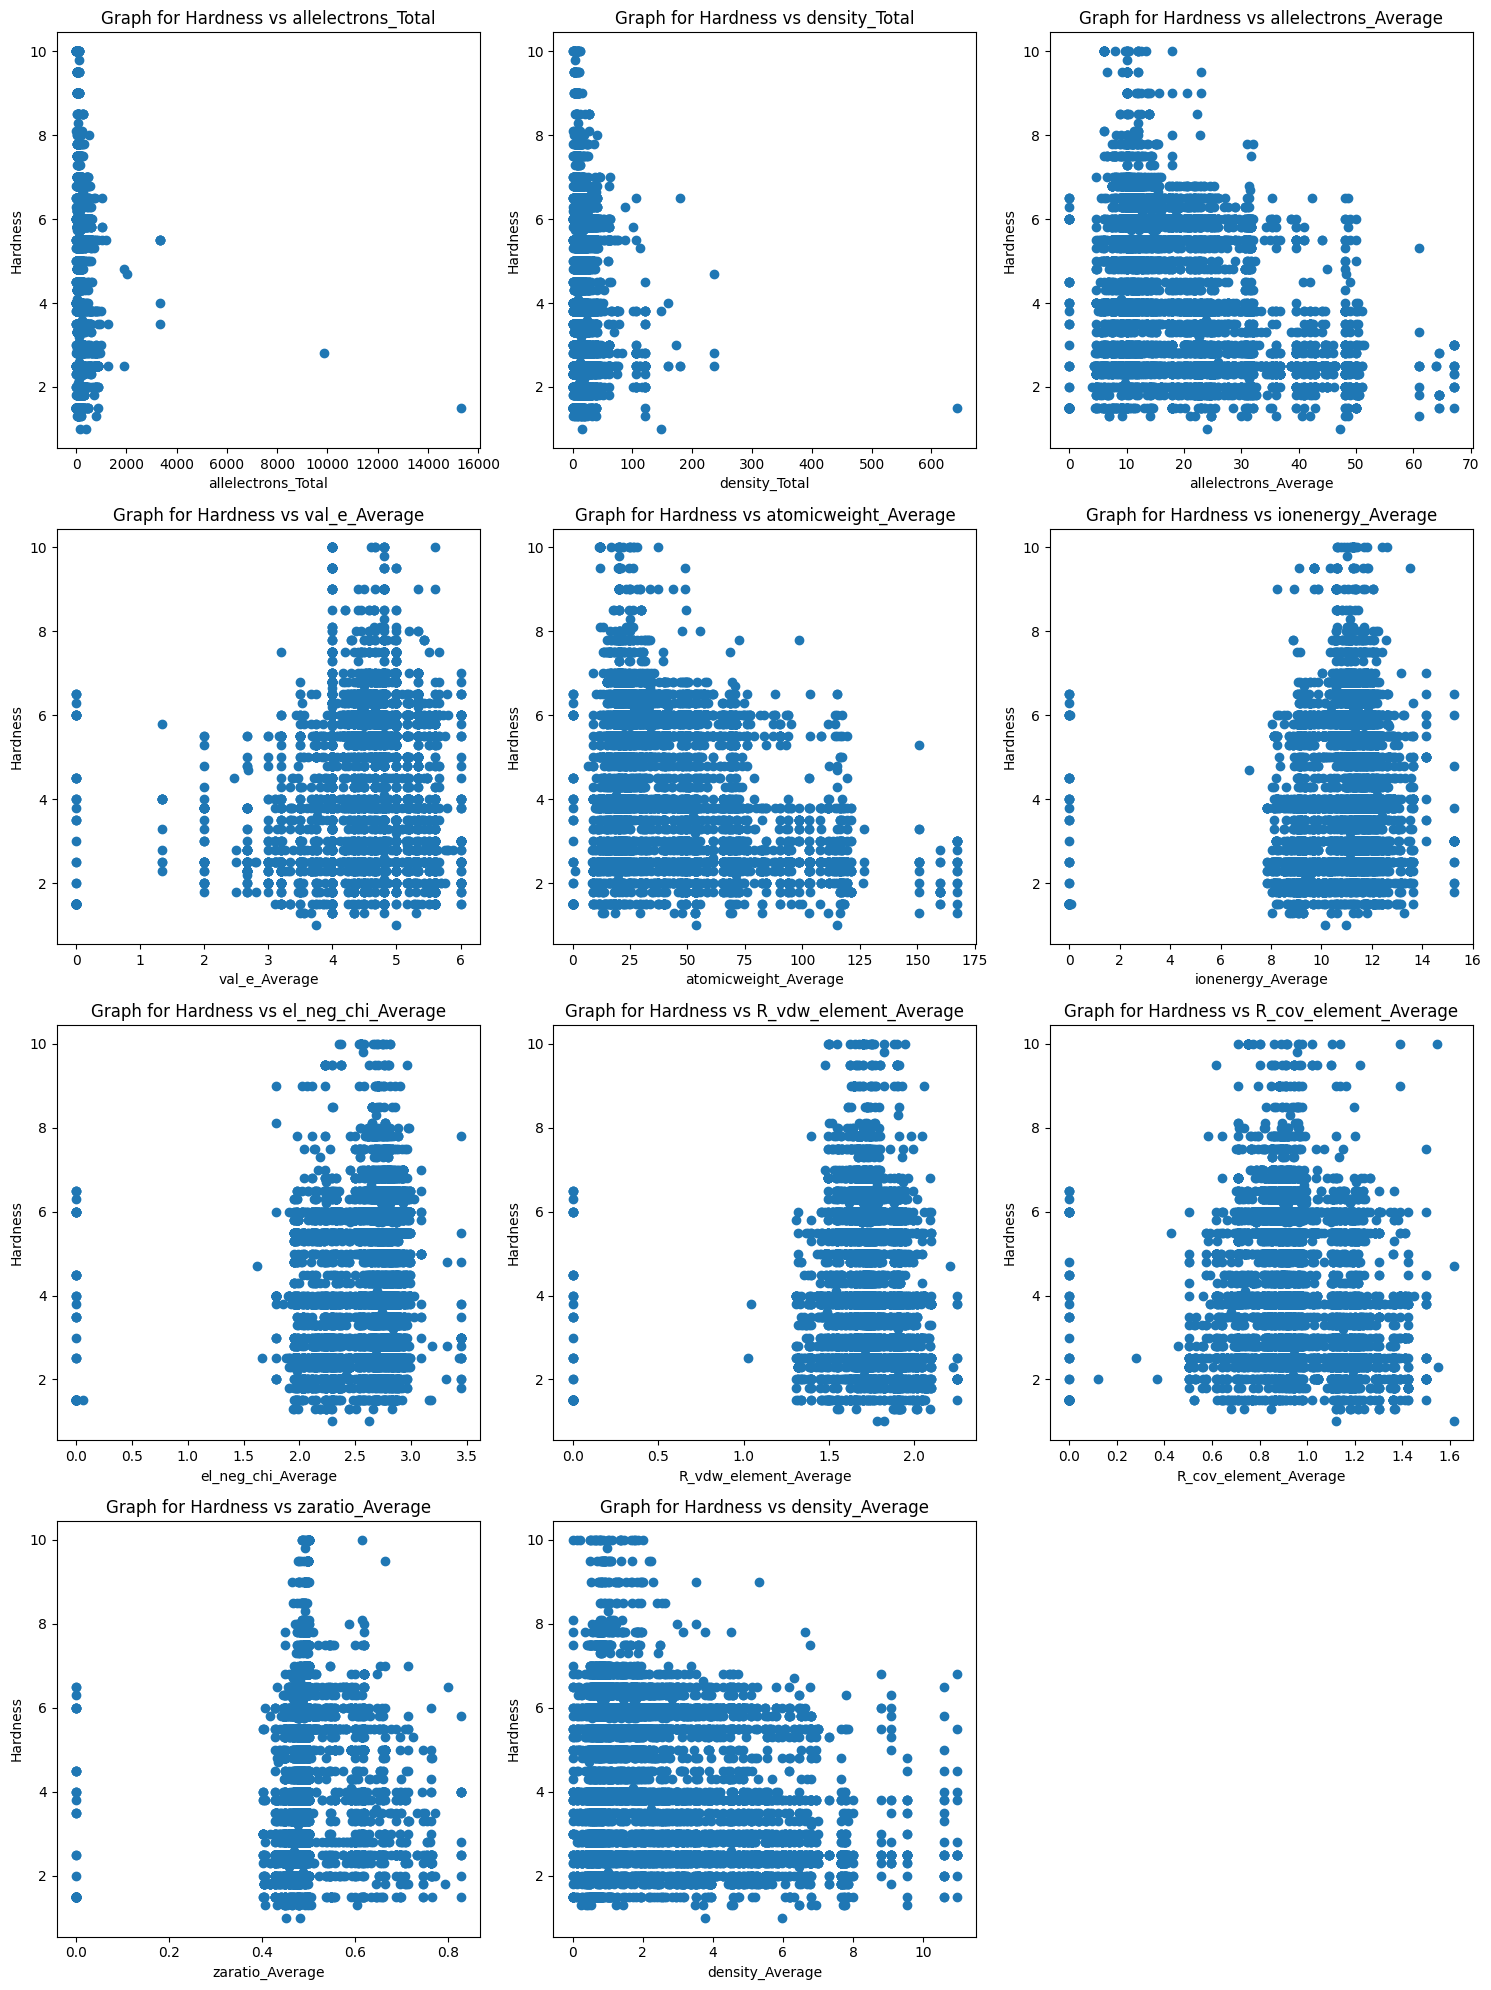

In [11]:
plt.figure(figsize=(15,20))
columns_to_plot = [col for col in data.columns if col != 'Hardness']
for i, col in enumerate(columns_to_plot, start=1):
  plt.subplot(4, 3, i)
  plt.scatter(x=data[col], y=data['Hardness'])
  plt.title(f'Graph for Hardness vs {col}')
  plt.xlabel(col)
  plt.ylabel('Hardness')

plt.tight_layout()
plt.show()

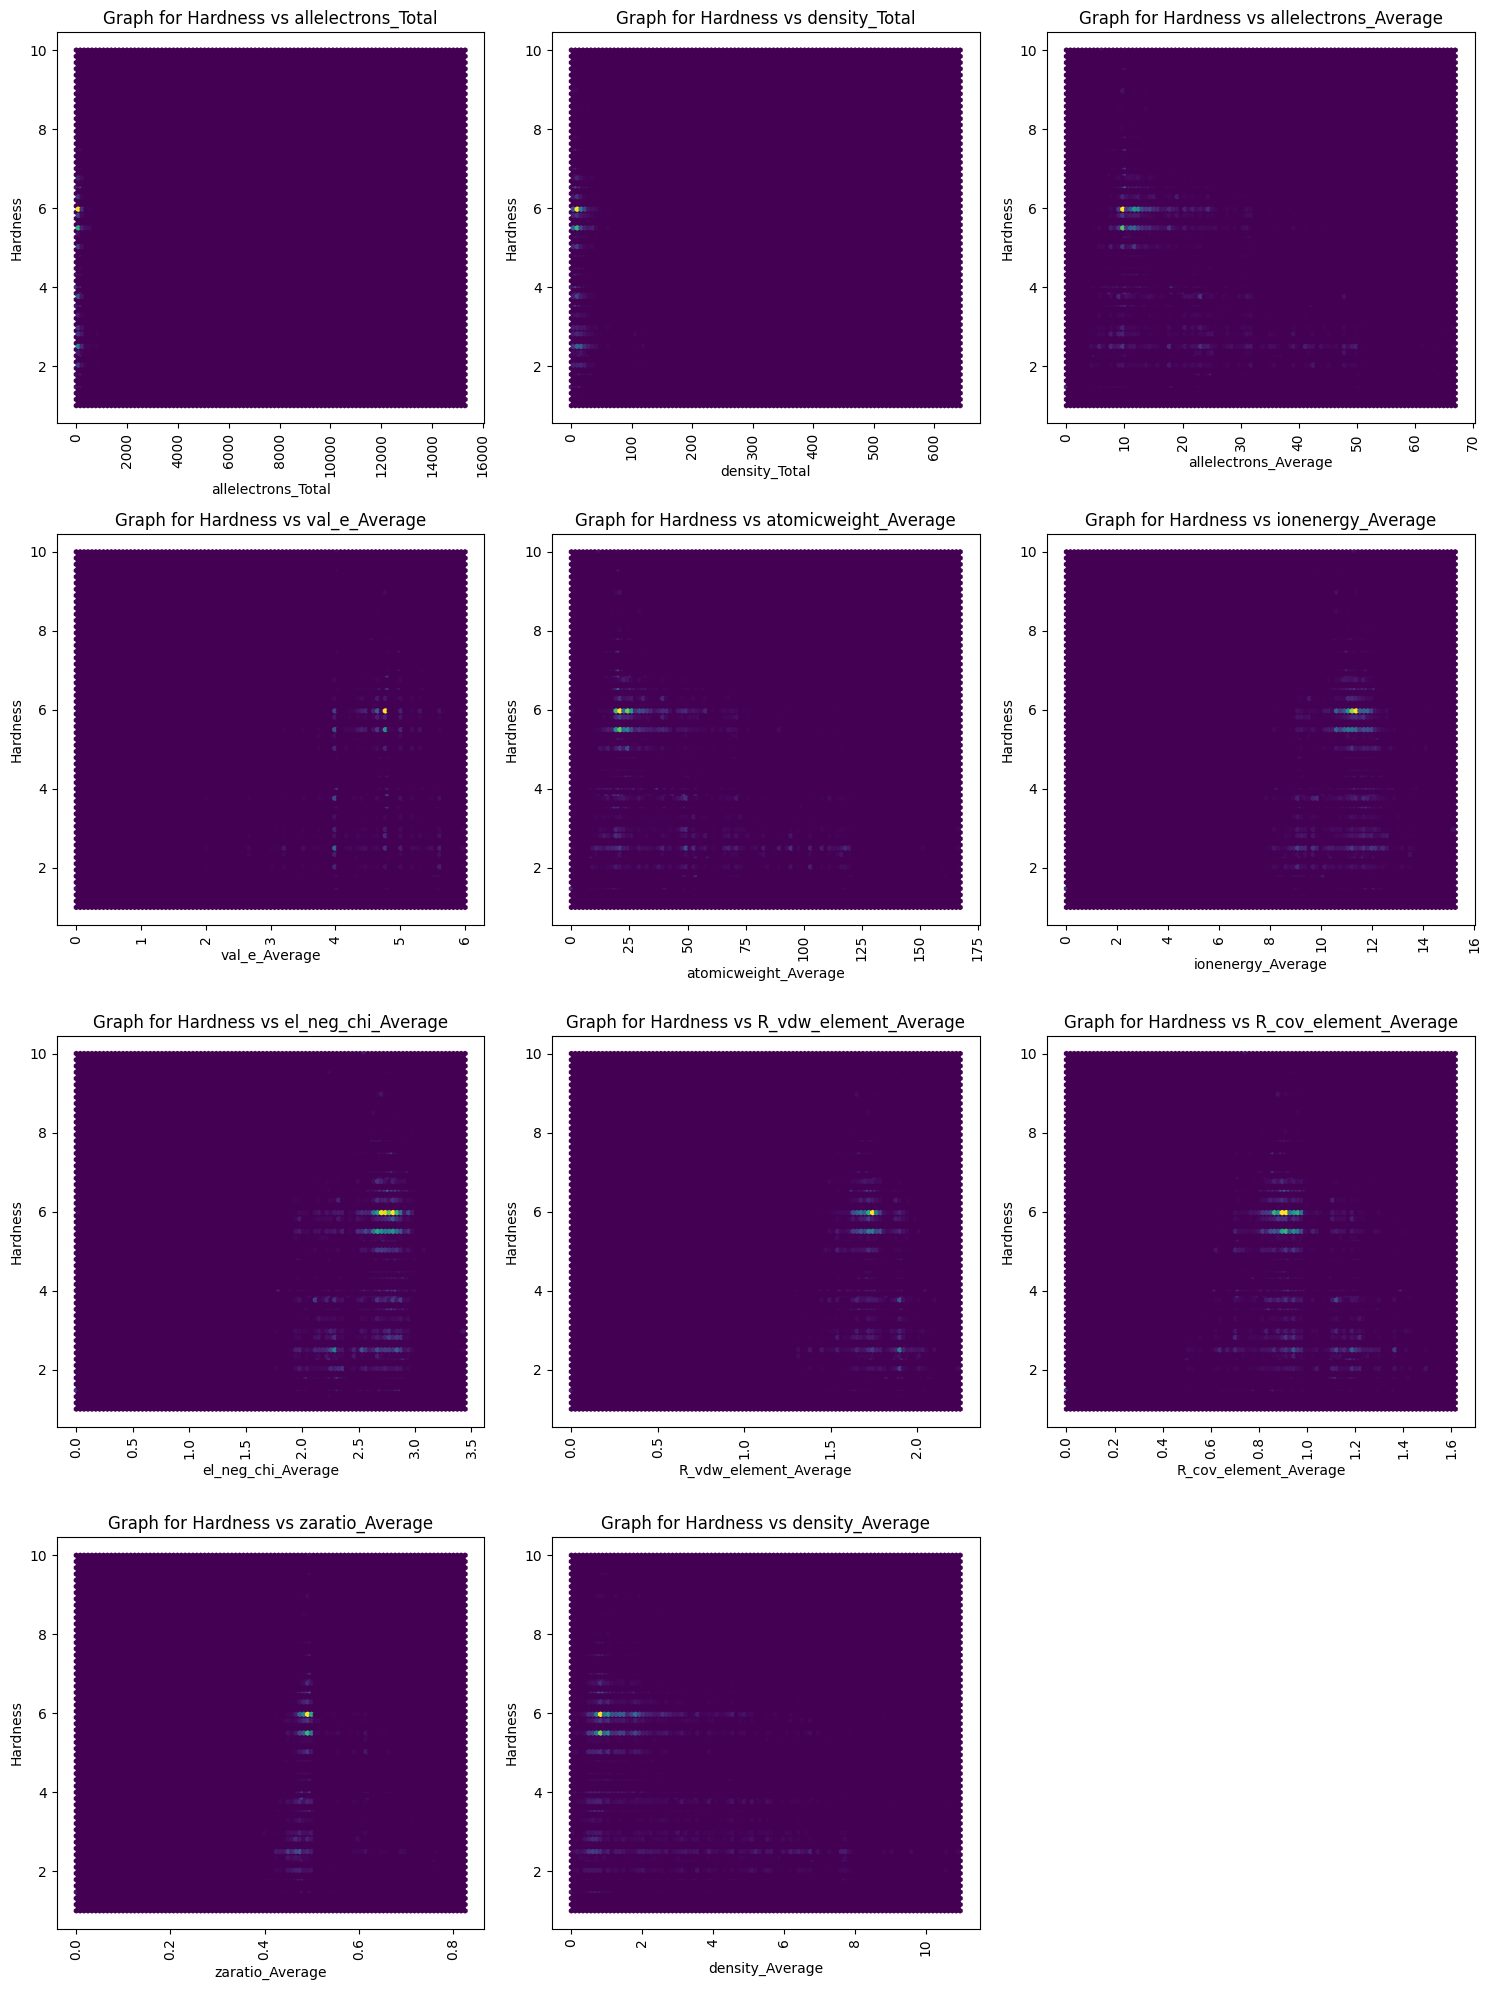

In [12]:
plt.figure(figsize=(15,20))
columns_to_plot = [col for col in data.columns if col != 'Hardness']
for i, col in enumerate(columns_to_plot, start=1):
  plt.subplot(4, 3, i)
  plt.hexbin(x=data[col], y=data['Hardness'])
  plt.title(f'Graph for Hardness vs {col}')
  plt.xlabel(col)
  plt.xticks(rotation=90)
  plt.ylabel('Hardness')

plt.tight_layout()
plt.show()

REMARKS: From the scatterplots we can see interesting pattern that lots of horizontal structures. This suggests that multiple data have the same hardness value. The hexbin plot showing us that eventhough the data are scattered and seems to be distributed accross all hardness value, it is actually concentrated in the hardness value of 5.5-6. In the next section we'll use boxplot to identify those outliers and cap them.

## EXPLORATORY DATA ANALYSIS: OUTLIERS AND ANOMALIES CLEANING

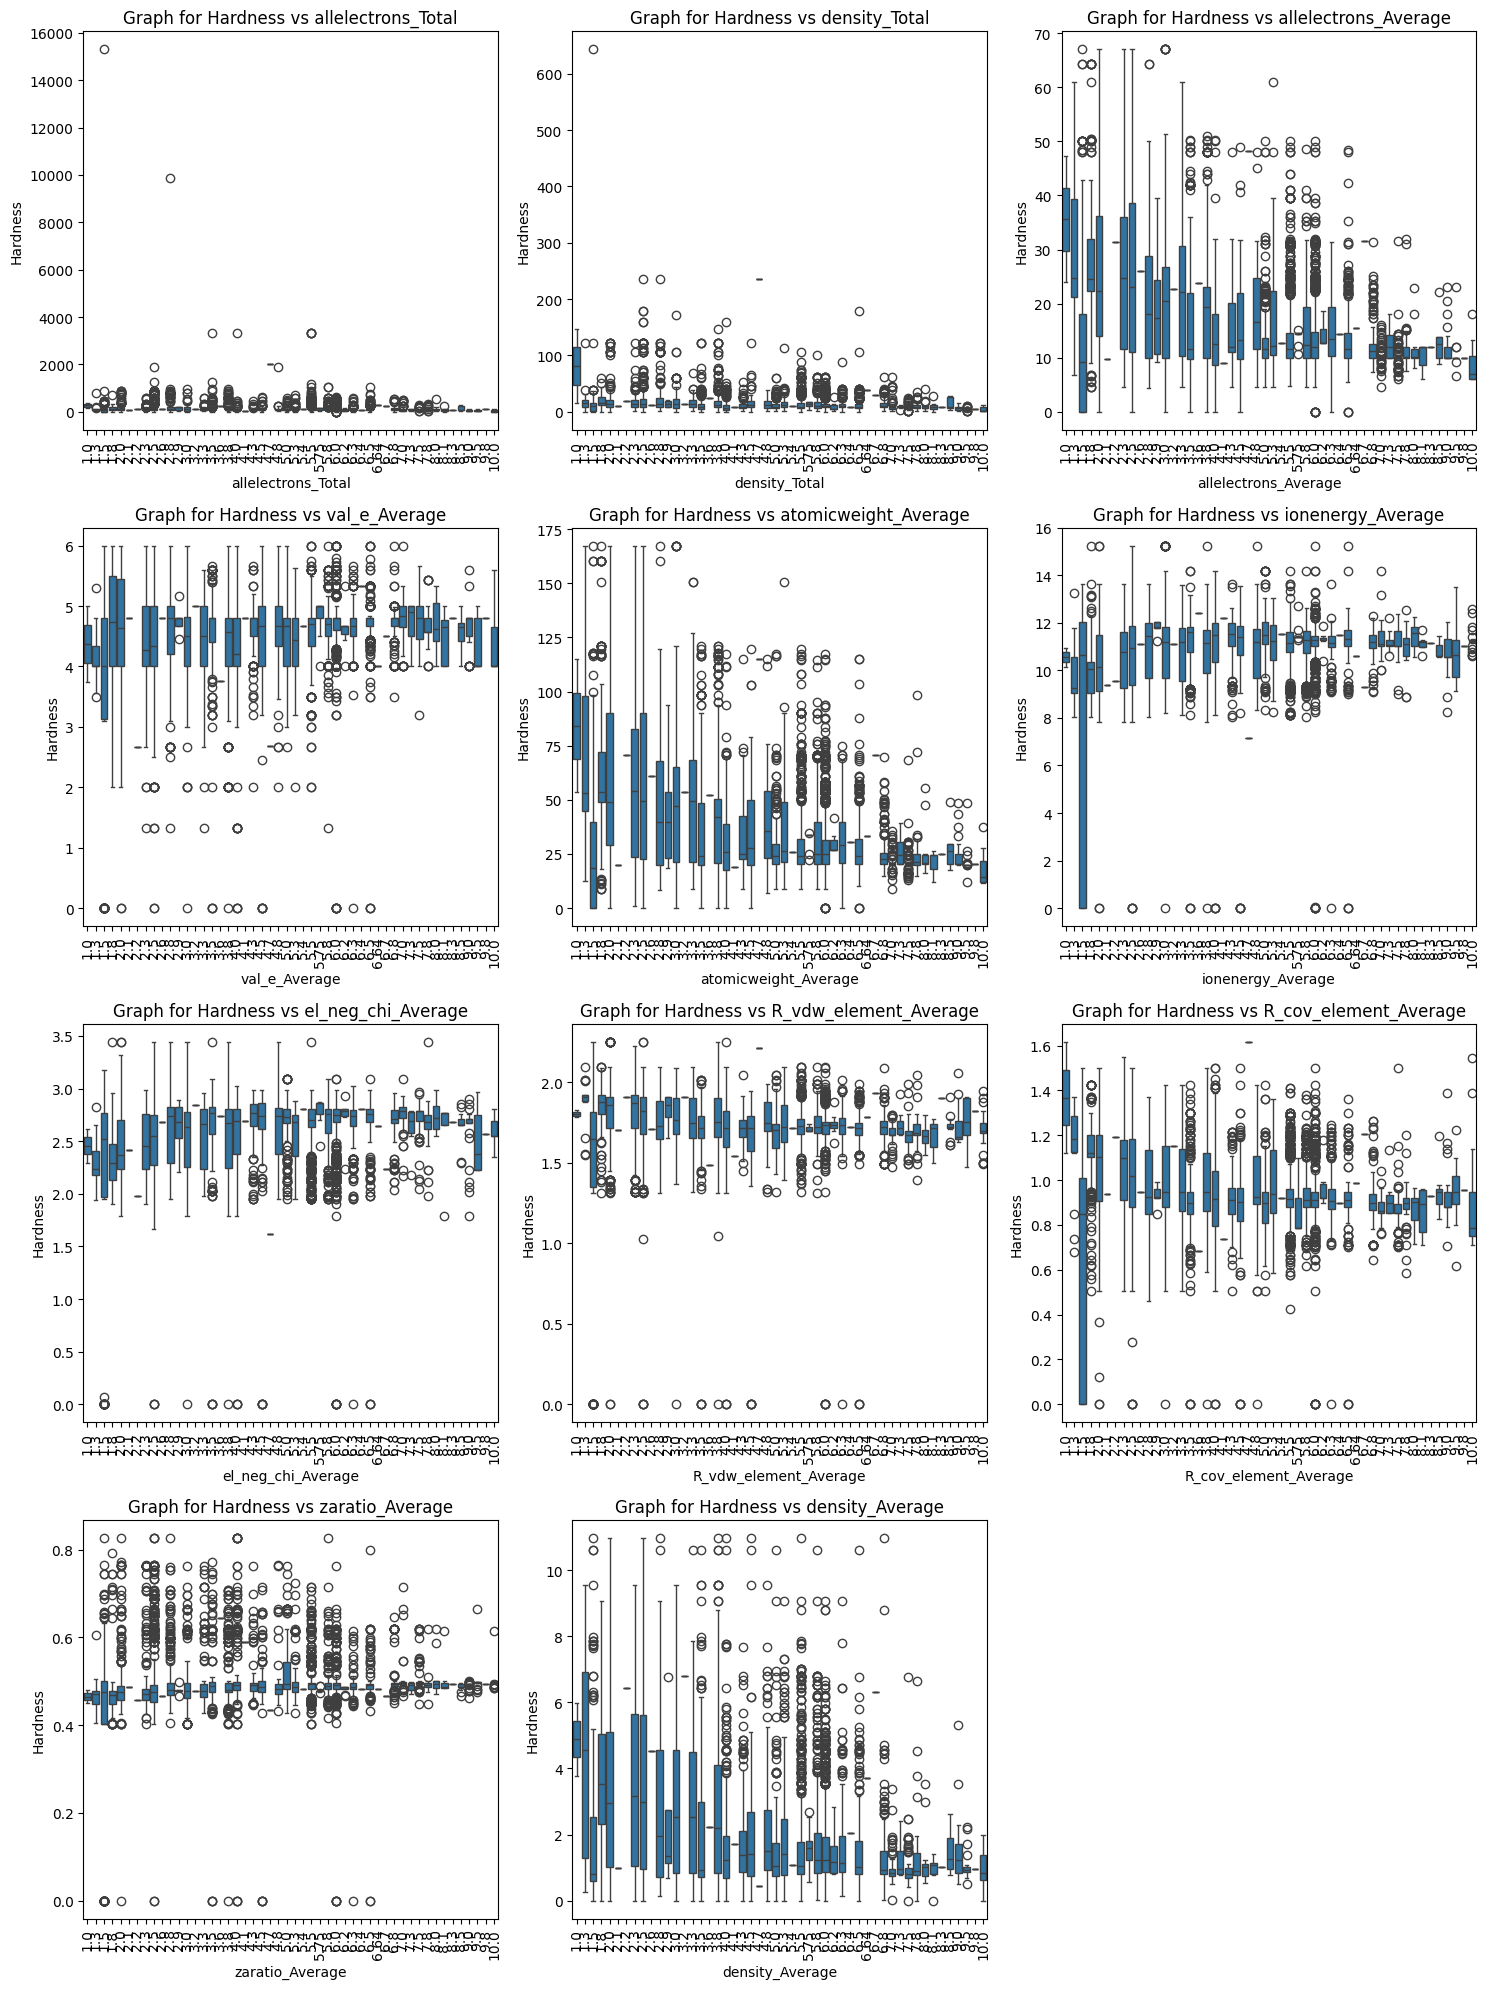

In [13]:
plt.figure(figsize=(15,20))
columns_to_plot = [col for col in data.columns if col != 'Hardness']
for i, col in enumerate(columns_to_plot, start=1):
  plt.subplot(4, 3, i)
  sns.boxplot(y=data[col], x=data['Hardness'])
  plt.title(f'Graph for Hardness vs {col}')
  plt.xlabel(col)
  plt.xticks(rotation=90)
  plt.ylabel('Hardness')

plt.tight_layout()
plt.show()

REMARKS: Upon checking the boxplot we can confirm anomalies in the data entry such as density of the items that have 0 value but has hardness values. Sometimes, we even see some instances have all of their values 0 but there's hardness value, therefore we will drop these anomalies. After that we shall check which features that redundant and eliminate it to reduce the dimension.  

In [14]:
preview = data.loc[(data['density_Total'] == 0) |
                   (data['allelectrons_Total'] == 0) |
                   (data['allelectrons_Average'] == 0) |
                   (data['val_e_Average'] == 0) |
                   (data['ionenergy_Average'] == 0) |
                   (data['el_neg_chi_Average'] == 0) |
                   (data['R_cov_element_Average'] == 0) |
                   (data['zaratio_Average'] == 0) |
                   (data['density_Average'] == 0) ]
preview

,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
22,0.0,0.755433,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.80454,2.5
99,42.0,0.000000,0.000000,4.000000,0.000000,0.026725,2.727000,1.767000,0.000000,0.000000,0.80212,6.0
272,198.0,9.148824,4.814815,3.459459,8.462067,13.266033,2.065000,1.394000,0.574595,0.770755,0.00000,2.0
390,40.0,1.743160,6.666667,4.000000,13.016128,12.700467,2.770000,1.476667,0.616667,0.663797,0.00000,5.0
524,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.50633,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...
10237,30.0,4.542664,11.000000,4.666667,22.521872,12.392110,2.766667,1.625000,0.000000,0.499074,1.02048,4.8
10242,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.82753,1.5
10321,0.0,0.505992,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.499404,0.01079,6.5
10378,120.0,15.550000,12.000000,4.000000,26.024935,10.600980,2.644000,1.794000,0.926000,0.499010,0.00000,5.0


In [15]:
data = data.drop(index=preview.index)
data.reset_index(drop=True)
data

,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
0,100.0,0.841611,10.000000,4.800000,20.612526,11.088100,2.766000,1.732000,0.860000,0.496070,0.91457,6.0
1,100.0,7.558488,10.000000,4.800000,20.298893,12.040830,2.755000,1.631000,0.910000,0.492719,0.71760,6.5
2,76.0,8.885992,15.600000,5.600000,33.739258,12.086300,2.828000,1.788000,0.864000,0.481478,1.50633,2.5
3,100.0,8.795296,10.000000,4.800000,20.213349,10.948500,2.648000,1.626000,0.936000,0.489272,0.78937,6.0
4,116.0,9.577996,11.600000,4.800000,24.988133,11.824480,2.766000,1.682000,0.896000,0.492736,1.86481,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10402,128.0,7.558488,12.000000,4.000000,26.385218,11.330440,2.644000,1.631000,0.892000,0.496070,1.79607,4.0
10403,30.0,1.743160,10.000000,5.333333,20.766935,14.163933,3.090000,1.556667,0.866667,0.480390,0.81480,5.0
10404,196.0,30.920000,24.500000,5.500000,53.490297,10.074300,2.295000,1.545000,1.120000,0.469715,2.11540,1.8
10405,38.0,1.553160,12.666667,4.666667,26.621687,11.290033,2.743333,1.756667,0.980000,0.486507,0.77755,6.0


In [16]:
# bin_store = []
# for j in data['Hardness'].values:
#   if 0.95 < j <= 1.5:
#     bin_store.append(1.0)
#   elif 1.5 < j <= 2.05:
#     bin_store.append(1.5)
#   elif 2.05 < j <= 2.55:
#     bin_store.append(2.0)
#   elif 2.55 < j <= 3.05:
#     bin_store.append(2.5)
#   elif 3.05 < j <= 3.55:
#     bin_store.append(3.0)
#   elif 3.55 < j <= 4.05:
#     bin_store.append(3.5)
#   elif 4.05 < j <= 4.55:
#     bin_store.append(4.0)
#   elif 4.55 < j <= 5.05:
#     bin_store.append(4.5)
#   elif 5.05 < j <= 5.55:
#     bin_store.append(5.0)
#   elif 5.55 < j <= 6.05:
#     bin_store.append(5.5)
#   elif 6.05 < j <= 6.55:
#     bin_store.append(6.0)
#   elif 6.55 < j <= 7.05:
#     bin_store.append(6.5)
#   elif 7.05 < j <= 7.55:
#     bin_store.append(7.0)
#   elif 7.55 < j <= 8.05:
#     bin_store.append(7.5)
#   elif 8.05 < j <= 8.55:
#     bin_store.append(8.0)
#   elif 8.55 < j <= 9.05:
#     bin_store.append(8.5)
#   elif 9.05 < j <= 9.55:
#     bin_store.append(9.0)
#   elif 9.55 < j <= 9.75:
#     bin_store.append(9.5)
#   else:
#     bin_store.append(10.0)

# data['bin_hardness'] = bin_store
# data

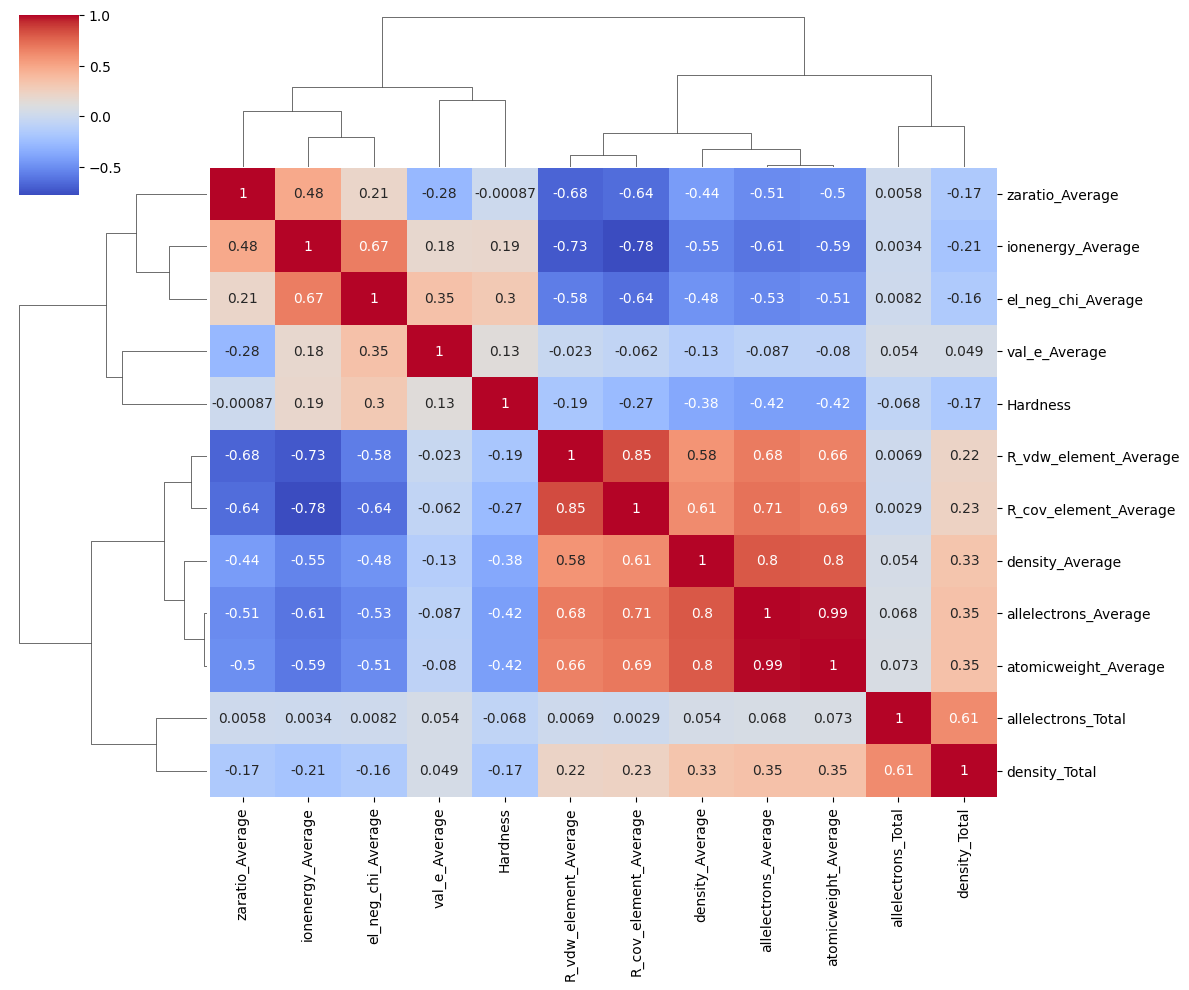

In [17]:
correlation = data.corr()

sns.clustermap(correlation, cmap='coolwarm', annot=True, figsize=(12, 10))
plt.show()

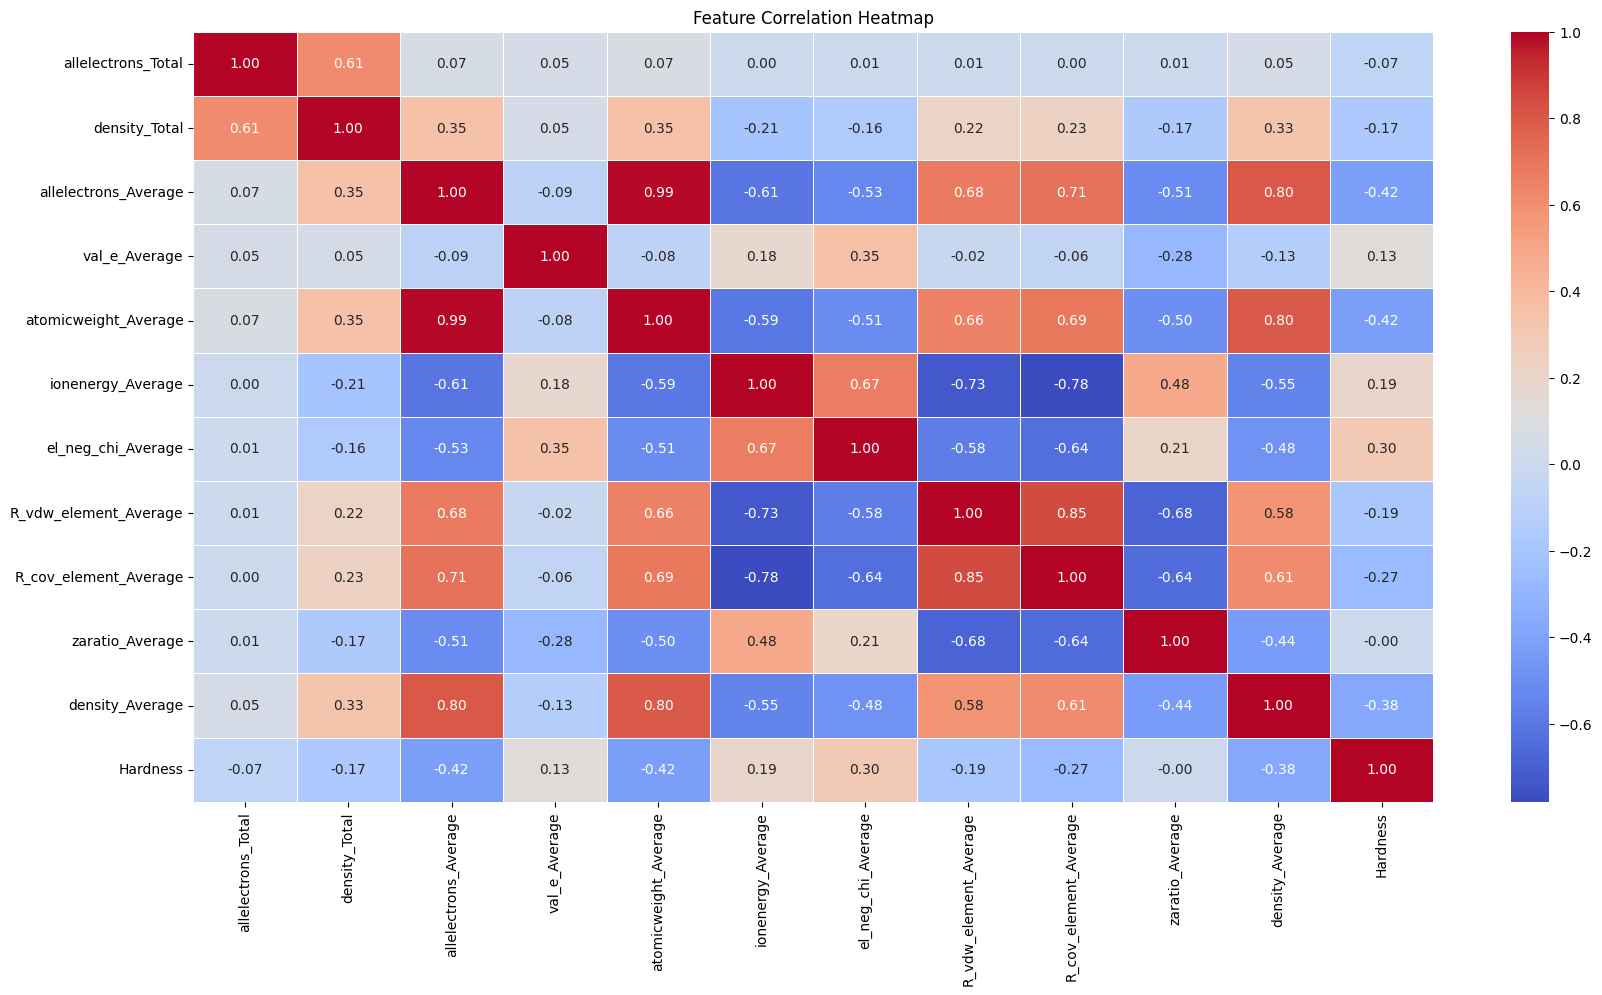

In [18]:
# FEATURE CORRELATIONS AFTER OUTLIERS CLEANE
corr_matrix = data.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [19]:
# DROP BECAUSE SOME FEATURES ARE REDUNDANT
data = data.drop(columns=['atomicweight_Average','R_vdw_element_Average'])
data

,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,ionenergy_Average,el_neg_chi_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
0,100.0,0.841611,10.000000,4.800000,11.088100,2.766000,0.860000,0.496070,0.91457,6.0
1,100.0,7.558488,10.000000,4.800000,12.040830,2.755000,0.910000,0.492719,0.71760,6.5
2,76.0,8.885992,15.600000,5.600000,12.086300,2.828000,0.864000,0.481478,1.50633,2.5
3,100.0,8.795296,10.000000,4.800000,10.948500,2.648000,0.936000,0.489272,0.78937,6.0
4,116.0,9.577996,11.600000,4.800000,11.824480,2.766000,0.896000,0.492736,1.86481,6.0
...,...,...,...,...,...,...,...,...,...,...
10402,128.0,7.558488,12.000000,4.000000,11.330440,2.644000,0.892000,0.496070,1.79607,4.0
10403,30.0,1.743160,10.000000,5.333333,14.163933,3.090000,0.866667,0.480390,0.81480,5.0
10404,196.0,30.920000,24.500000,5.500000,10.074300,2.295000,1.120000,0.469715,2.11540,1.8
10405,38.0,1.553160,12.666667,4.666667,11.290033,2.743333,0.980000,0.486507,0.77755,6.0


REMARKS: Now that we have deleted some anomalies and redundant features, we now have some spaces to do Feature Engineering that can enhance the regression signal to the target features. We will also do log transformation on some features that clustered vertically like 'density_Total' and 'allelectrons_Total' to increase correlation signal. After that we will cap the outliers.

In [20]:
data['log_density_Total'] = np.log10(data['density_Total'])
data['log_allelectrons_Total'] = np.log10(data['allelectrons_Total'])
data['poly_allelectrons_Total'] = ((data['allelectrons_Total']**2) + 2*(data['allelectrons_Total'])*(data['el_neg_chi_Average']) + (data['el_neg_chi_Average']**2)) / 1000

data

,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,ionenergy_Average,el_neg_chi_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness,log_density_Total,log_allelectrons_Total,poly_allelectrons_Total
0,100.0,0.841611,10.000000,4.800000,11.088100,2.766000,0.860000,0.496070,0.91457,6.0,-0.074889,2.000000,10.560851
1,100.0,7.558488,10.000000,4.800000,12.040830,2.755000,0.910000,0.492719,0.71760,6.5,0.878435,2.000000,10.558590
2,76.0,8.885992,15.600000,5.600000,12.086300,2.828000,0.864000,0.481478,1.50633,2.5,0.948706,1.880814,6.213854
3,100.0,8.795296,10.000000,4.800000,10.948500,2.648000,0.936000,0.489272,0.78937,6.0,0.944250,2.000000,10.536612
4,116.0,9.577996,11.600000,4.800000,11.824480,2.766000,0.896000,0.492736,1.86481,6.0,0.981275,2.064458,14.105363
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10402,128.0,7.558488,12.000000,4.000000,11.330440,2.644000,0.892000,0.496070,1.79607,4.0,0.878435,2.107210,17.067855
10403,30.0,1.743160,10.000000,5.333333,14.163933,3.090000,0.866667,0.480390,0.81480,5.0,0.241337,1.477121,1.094948
10404,196.0,30.920000,24.500000,5.500000,10.074300,2.295000,1.120000,0.469715,2.11540,1.8,1.490239,2.292256,39.320907
10405,38.0,1.553160,12.666667,4.666667,11.290033,2.743333,0.980000,0.486507,0.77755,6.0,0.191216,1.579784,1.660019


In [21]:
def cap_outliers_by_group(df, parameter, group_col, iqr_multiplier=1.5):
    df_capped = df.copy()

    for group, group_df in df.groupby(group_col):
        q1 = group_df[parameter].quantile(0.25)
        q3 = group_df[parameter].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - iqr_multiplier * iqr
        upper = q3 + iqr_multiplier * iqr

        mask = df[group_col] == group
        df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)

    return df_capped

columns_to_cap = [col for col in data.columns if col != 'Hardness']
# data_grouped_cleaned = data_pastry.copy()

for col in columns_to_cap:
    data = cap_outliers_by_group(data, col, group_col='Hardness')

data

,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,ionenergy_Average,el_neg_chi_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness,log_density_Total,log_allelectrons_Total,poly_allelectrons_Total
0,100.000,0.841611,10.000000,4.800000,11.088100,2.766000,0.860000,0.496070,0.91457,6.0,0.510586,2.000000,10.560851
1,100.000,7.558488,10.000000,4.800000,12.040830,2.755000,0.910000,0.492719,0.71760,6.5,0.878435,2.000000,10.558590
2,76.000,8.885992,15.600000,5.600000,12.086300,2.828000,0.864000,0.481478,1.50633,2.5,0.948706,1.880814,6.213854
3,100.000,8.795296,10.000000,4.800000,10.948500,2.648000,0.936000,0.489272,0.78937,6.0,0.944250,2.000000,10.536612
4,116.000,9.577996,11.600000,4.800000,11.824480,2.766000,0.896000,0.492736,1.86481,6.0,0.981275,2.064458,14.105363
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10402,128.000,7.558488,12.000000,4.000000,11.330440,2.644000,0.892000,0.496070,1.79607,4.0,0.878435,2.107210,17.067855
10403,30.000,1.743160,10.000000,5.333333,13.460020,3.012500,0.866667,0.480390,0.81480,5.0,0.342598,1.477121,1.094948
10404,196.000,30.920000,24.500000,5.500000,10.074300,2.295000,1.120000,0.469715,2.11540,1.8,1.490239,2.292256,39.320907
10405,38.000,1.553160,12.666667,4.666667,11.290033,2.743333,0.980000,0.486507,0.77755,6.0,0.510586,1.579784,1.660019


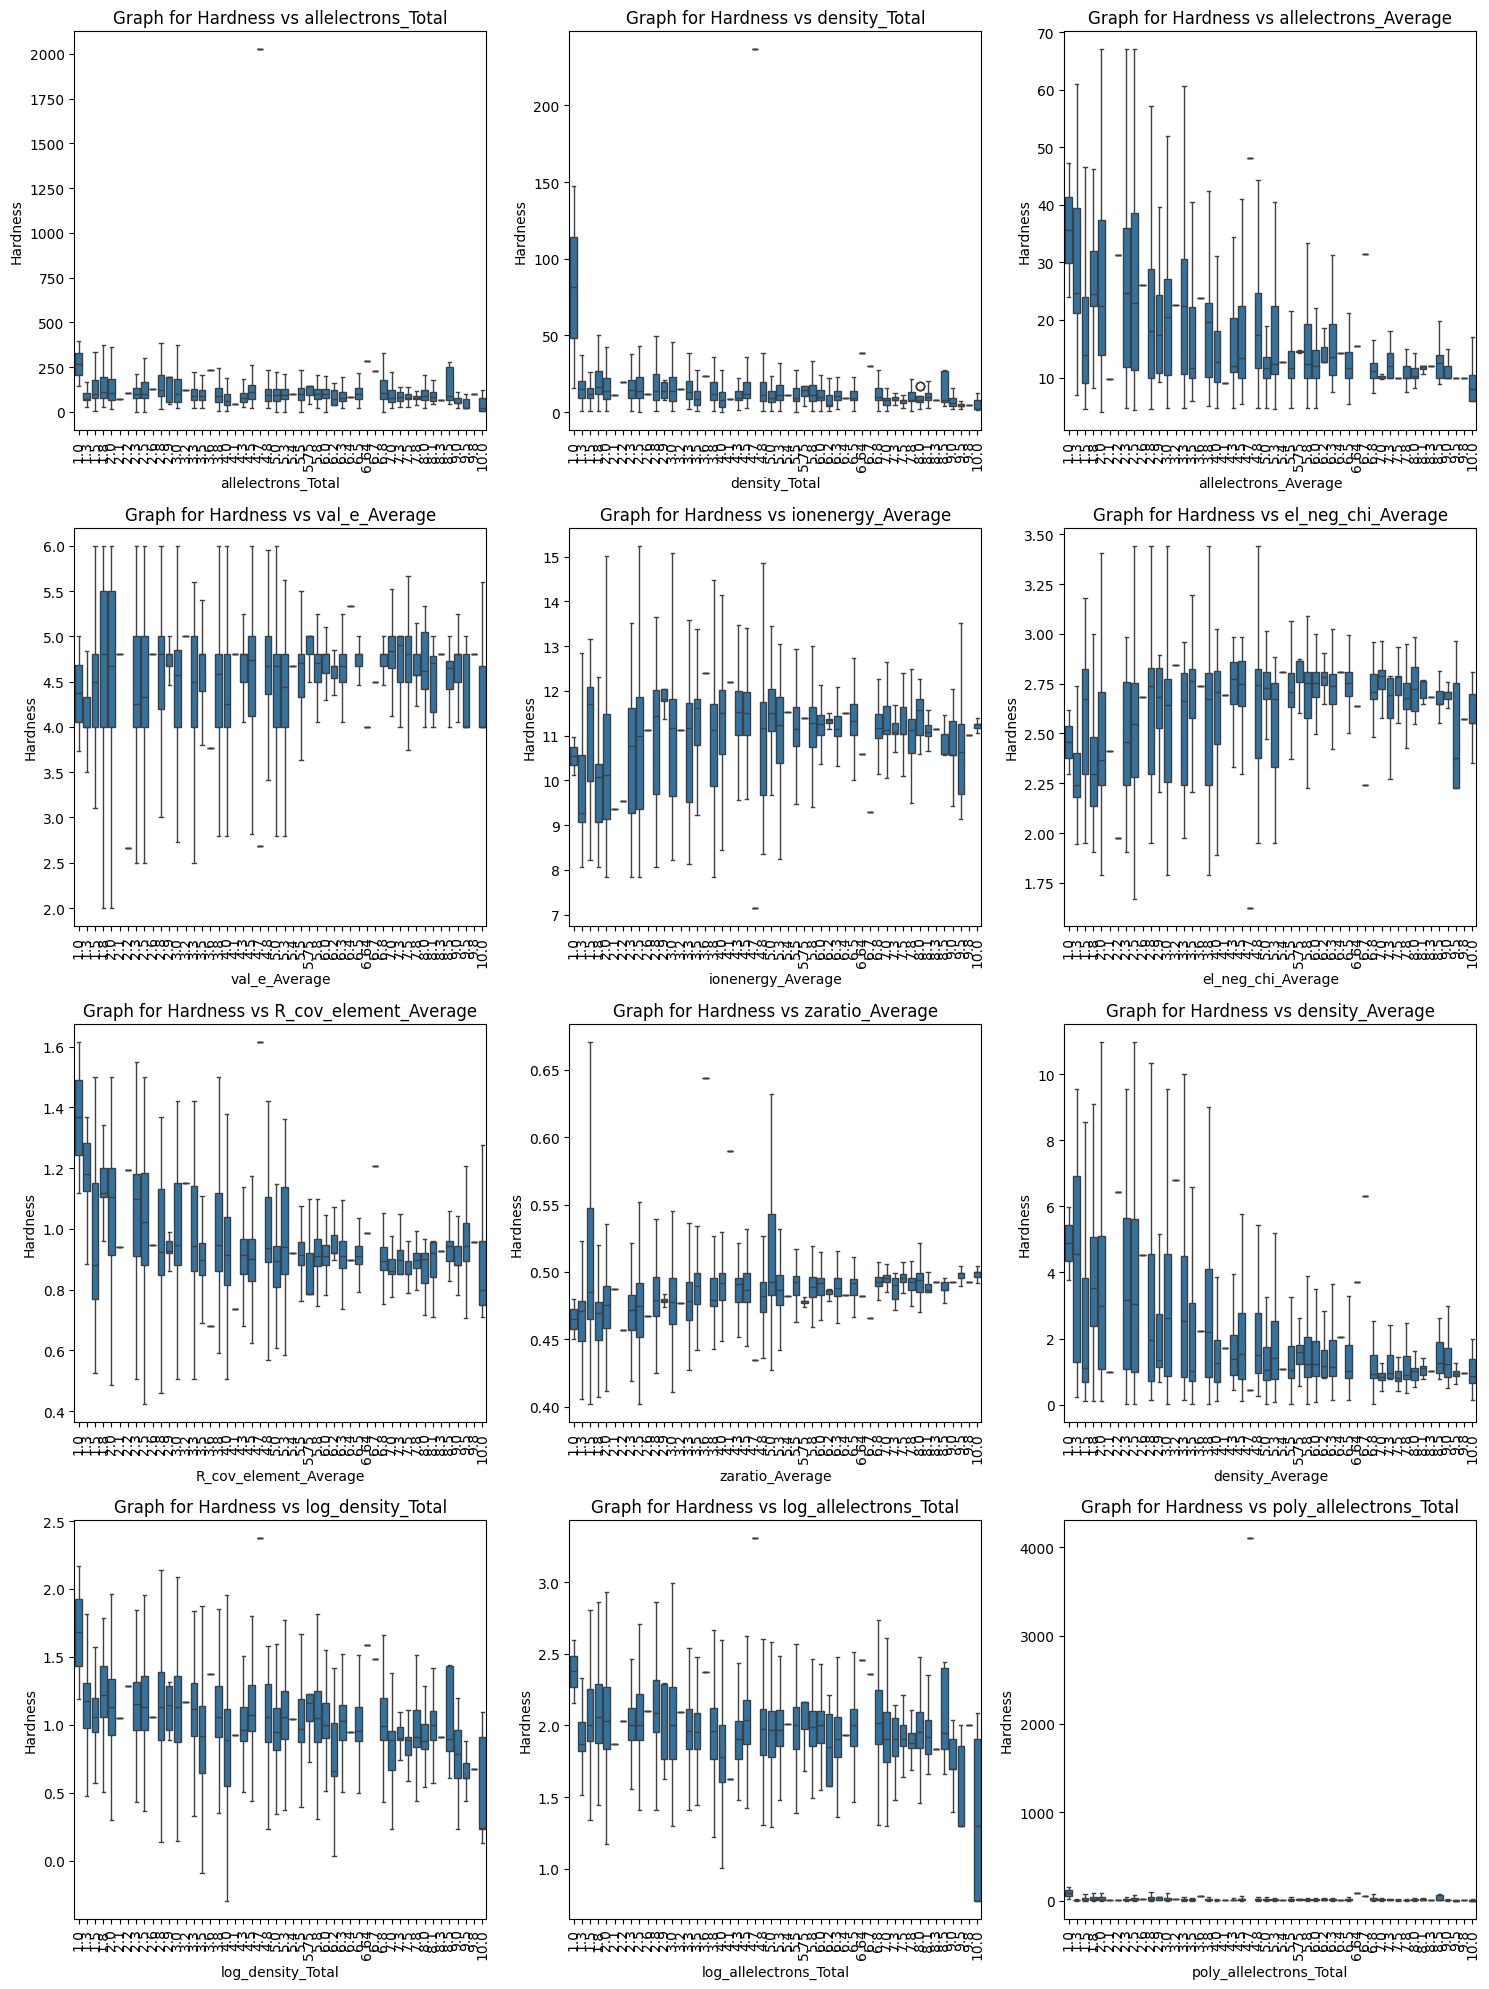

In [22]:
plt.figure(figsize=(15,20))
columns_to_plot = [col for col in data.columns if col != 'Hardness' and col != 'outlier_flag_a']
for i, col in enumerate(columns_to_plot, start=1):
  plt.subplot(4, 3, i)
  sns.boxplot(y=data[col], x=data['Hardness'])
  plt.title(f'Graph for Hardness vs {col}')
  plt.xlabel(col)
  plt.xticks(rotation=90)
  plt.ylabel('Hardness')

plt.tight_layout()
plt.show()

REMARKS: Even after capping some outliers we still can see extreme values in most features. If we observe the boxplot above we can notice that in the boxplot there are small line (actually it's a box, but so small because the distribution is also small) located outside of the others distribution. We'll use `IsolationForest` to capture these outliers and eliminate them. However, if we do `Isolation Forest`, it might cause new outliers to exist again, therefore after we do the `Isolation Forest`, we shall cap the outliers again.

In [23]:
features_a = [col for col in data.columns if col != 'Hardness']
iso = IsolationForest(contamination=0.01, random_state=42)
data['outlier_flag_a'] = iso.fit_predict(data[features_a])

In [24]:
data = data.loc[(data['outlier_flag_a'] == 1), :]
data

,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,ionenergy_Average,el_neg_chi_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness,log_density_Total,log_allelectrons_Total,poly_allelectrons_Total,outlier_flag_a
0,100.000,0.841611,10.000000,4.800000,11.088100,2.766000,0.860000,0.496070,0.91457,6.0,0.510586,2.000000,10.560851,1
1,100.000,7.558488,10.000000,4.800000,12.040830,2.755000,0.910000,0.492719,0.71760,6.5,0.878435,2.000000,10.558590,1
2,76.000,8.885992,15.600000,5.600000,12.086300,2.828000,0.864000,0.481478,1.50633,2.5,0.948706,1.880814,6.213854,1
3,100.000,8.795296,10.000000,4.800000,10.948500,2.648000,0.936000,0.489272,0.78937,6.0,0.944250,2.000000,10.536612,1
4,116.000,9.577996,11.600000,4.800000,11.824480,2.766000,0.896000,0.492736,1.86481,6.0,0.981275,2.064458,14.105363,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10402,128.000,7.558488,12.000000,4.000000,11.330440,2.644000,0.892000,0.496070,1.79607,4.0,0.878435,2.107210,17.067855,1
10403,30.000,1.743160,10.000000,5.333333,13.460020,3.012500,0.866667,0.480390,0.81480,5.0,0.342598,1.477121,1.094948,1
10404,196.000,30.920000,24.500000,5.500000,10.074300,2.295000,1.120000,0.469715,2.11540,1.8,1.490239,2.292256,39.320907,1
10405,38.000,1.553160,12.666667,4.666667,11.290033,2.743333,0.980000,0.486507,0.77755,6.0,0.510586,1.579784,1.660019,1


In [25]:
def cap_outliers_by_group(df, parameter, group_col, iqr_multiplier=1.5):
    df_capped = df.copy()

    for group, group_df in df.groupby(group_col):
        q1 = group_df[parameter].quantile(0.25)
        q3 = group_df[parameter].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - iqr_multiplier * iqr
        upper = q3 + iqr_multiplier * iqr

        mask = df[group_col] == group
        df_capped.loc[mask, parameter] = df.loc[mask, parameter].clip(lower, upper)

    return df_capped

columns_to_cap = [col for col in data.columns if col != 'Hardness']
# data_grouped_cleaned = data_pastry.copy()

for col in columns_to_cap:
    data = cap_outliers_by_group(data, col, group_col='Hardness')

data

,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,ionenergy_Average,el_neg_chi_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness,log_density_Total,log_allelectrons_Total,poly_allelectrons_Total,outlier_flag_a
0,100.000,0.841611,10.000000,4.800000,11.088100,2.766000,0.860000,0.496070,0.91457,6.0,0.510586,2.000000,10.560851,1
1,100.000,7.558488,10.000000,4.800000,12.040830,2.755000,0.910000,0.492719,0.71760,6.5,0.878435,2.000000,10.558590,1
2,76.000,8.885992,15.600000,5.600000,12.086300,2.828000,0.864000,0.481478,1.50633,2.5,0.948706,1.880814,6.213854,1
3,100.000,8.795296,10.000000,4.800000,10.948500,2.648000,0.936000,0.489272,0.78937,6.0,0.944250,2.000000,10.536612,1
4,116.000,9.577996,11.600000,4.800000,11.824480,2.766000,0.896000,0.492736,1.86481,6.0,0.981275,2.064458,14.105363,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10402,128.000,7.558488,12.000000,4.000000,11.330440,2.644000,0.892000,0.496070,1.79607,4.0,0.878435,2.107210,17.067855,1
10403,30.000,1.743160,10.000000,5.333333,13.460020,3.012500,0.866667,0.480390,0.81480,5.0,0.342598,1.477121,1.094948,1
10404,196.000,30.920000,24.500000,5.500000,10.074300,2.295000,1.120000,0.469715,2.11540,1.8,1.490239,2.292256,39.320907,1
10405,38.000,1.553160,12.666667,4.666667,11.290033,2.743333,0.980000,0.486507,0.77755,6.0,0.510586,1.579784,1.660019,1


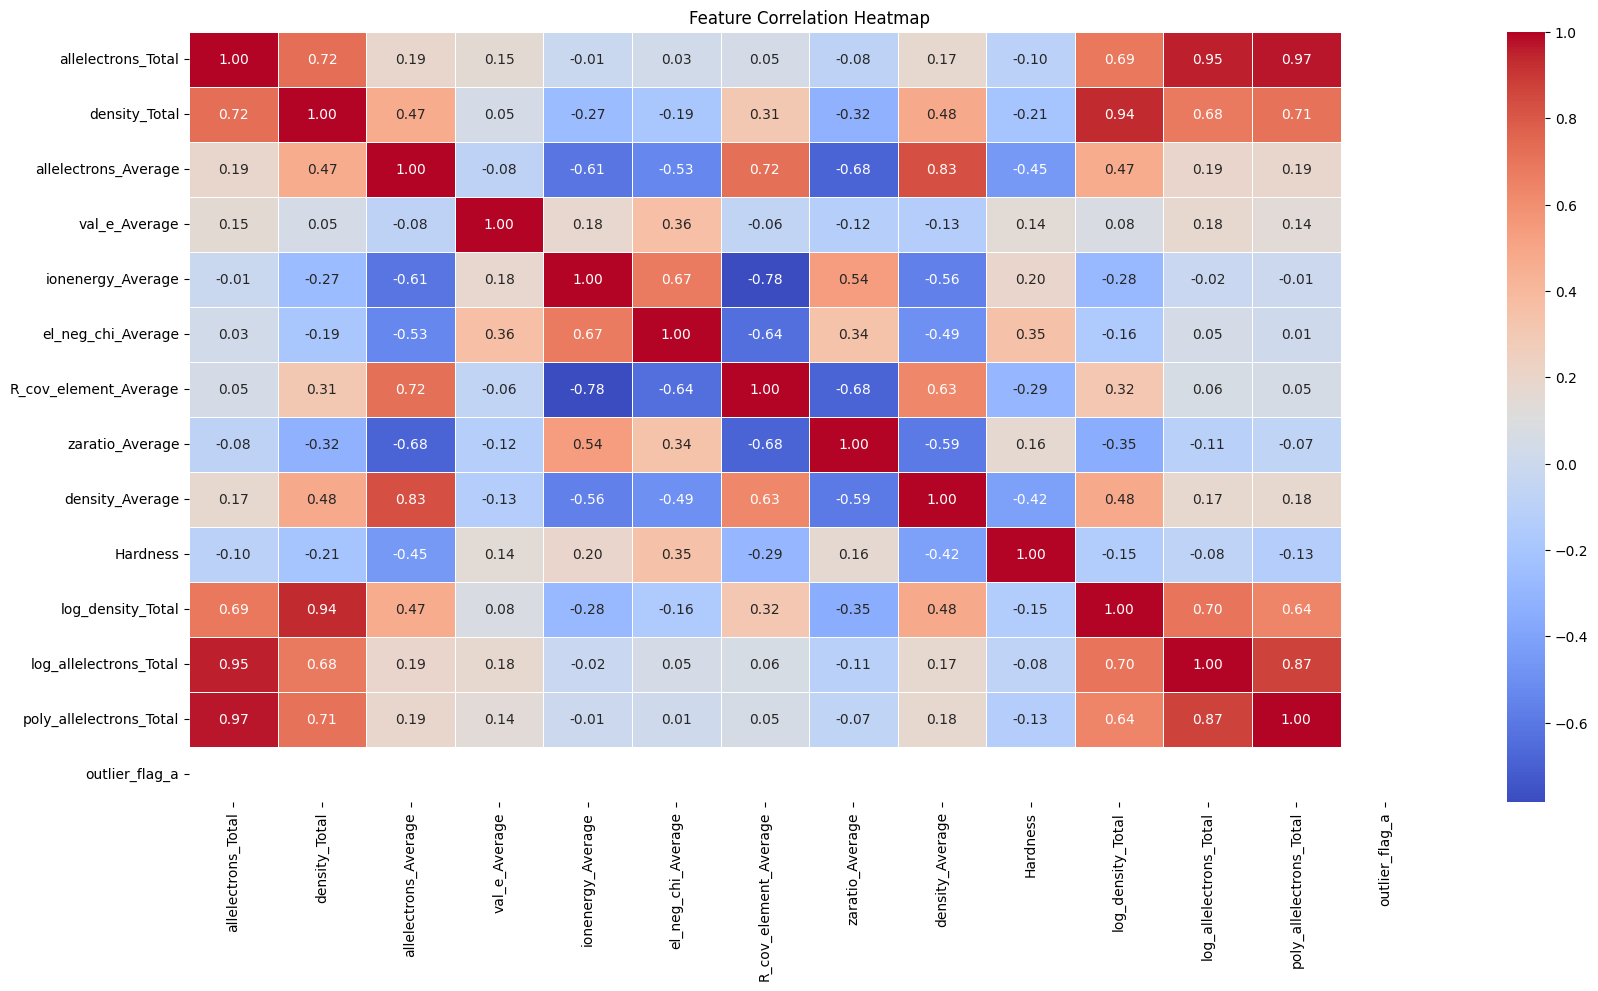

In [26]:
# FEATURE CORRELATIONS AFTER OUTLIERS CLEANE
corr_matrix = data.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [27]:
feature_corr = data.corr()['Hardness'].sort_values(ascending=False)
feature_corr

,Hardness
Hardness,1.000000
el_neg_chi_Average,0.351460
ionenergy_Average,0.198877
zaratio_Average,0.164937
val_e_Average,0.144677
log_allelectrons_Total,-0.076528
allelectrons_Total,-0.099960
poly_allelectrons_Total,-0.133902
log_density_Total,-0.148272
density_Total,-0.207374


In [28]:
# to_drop = []
# for i, j in feature_corr.items():
#   if abs(j) <= 0.18:
#     to_drop.append(i)

# # to_drop.append('outlier_flag_a')
# to_drop

In [29]:
data = data.drop(columns='outlier_flag_a')
# data = data.drop(columns=['log_allelectrons_Total', 'log_density_Total'])
data

,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,ionenergy_Average,el_neg_chi_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness,log_density_Total,log_allelectrons_Total,poly_allelectrons_Total
0,100.000,0.841611,10.000000,4.800000,11.088100,2.766000,0.860000,0.496070,0.91457,6.0,0.510586,2.000000,10.560851
1,100.000,7.558488,10.000000,4.800000,12.040830,2.755000,0.910000,0.492719,0.71760,6.5,0.878435,2.000000,10.558590
2,76.000,8.885992,15.600000,5.600000,12.086300,2.828000,0.864000,0.481478,1.50633,2.5,0.948706,1.880814,6.213854
3,100.000,8.795296,10.000000,4.800000,10.948500,2.648000,0.936000,0.489272,0.78937,6.0,0.944250,2.000000,10.536612
4,116.000,9.577996,11.600000,4.800000,11.824480,2.766000,0.896000,0.492736,1.86481,6.0,0.981275,2.064458,14.105363
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10402,128.000,7.558488,12.000000,4.000000,11.330440,2.644000,0.892000,0.496070,1.79607,4.0,0.878435,2.107210,17.067855
10403,30.000,1.743160,10.000000,5.333333,13.460020,3.012500,0.866667,0.480390,0.81480,5.0,0.342598,1.477121,1.094948
10404,196.000,30.920000,24.500000,5.500000,10.074300,2.295000,1.120000,0.469715,2.11540,1.8,1.490239,2.292256,39.320907
10405,38.000,1.553160,12.666667,4.666667,11.290033,2.743333,0.980000,0.486507,0.77755,6.0,0.510586,1.579784,1.660019


## MACHINE LEARNING MODELLING

We now will do Machine Learning modelling by using 4 regressor model namely: `RandomForestRegressor`, `LGBMRegressor`, `XGBoostRegressor` and `GradientBoostingRegressor`. After that we will check the performance of each model by using Median Absolute Error and decide which one has smallest error percentage.

In [30]:
X_main = data.drop(columns='Hardness')
y_main = data['Hardness']

x_train, x_test, y_train, y_test = train_test_split(X_main, y_main, test_size=0.2, random_state=42)

In [32]:
model_rf = RandomForestRegressor(max_depth=30, n_estimators=120, random_state=42, verbose=2)
model_rf.fit(x_train, y_train)
y_pred_rf = model_rf.predict(x_test)

medae_score = median_absolute_error(y_test, y_pred_rf)
print(f'Median Score Error is: {medae_score}')

building tree 1 of 120
building tree 2 of 120
building tree 3 of 120
building tree 4 of 120
building tree 5 of 120
building tree 6 of 120
building tree 7 of 120
building tree 8 of 120
building tree 9 of 120
building tree 10 of 120
building tree 11 of 120
building tree 12 of 120
building tree 13 of 120
building tree 14 of 120
building tree 15 of 120
building tree 16 of 120
building tree 17 of 120
building tree 18 of 120
building tree 19 of 120
building tree 20 of 120
building tree 21 of 120
building tree 22 of 120
building tree 23 of 120
building tree 24 of 120
building tree 25 of 120
building tree 26 of 120
building tree 27 of 120
building tree 28 of 120
building tree 29 of 120
building tree 30 of 120
building tree 31 of 120
building tree 32 of 120
building tree 33 of 120
building tree 34 of 120
building tree 35 of 120
building tree 36 of 120
building tree 37 of 120
building tree 38 of 120
building tree 39 of 120
building tree 40 of 120


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    4.3s


building tree 41 of 120
building tree 42 of 120
building tree 43 of 120
building tree 44 of 120
building tree 45 of 120
building tree 46 of 120
building tree 47 of 120
building tree 48 of 120
building tree 49 of 120
building tree 50 of 120
building tree 51 of 120
building tree 52 of 120
building tree 53 of 120
building tree 54 of 120
building tree 55 of 120
building tree 56 of 120
building tree 57 of 120
building tree 58 of 120
building tree 59 of 120
building tree 60 of 120
building tree 61 of 120
building tree 62 of 120
building tree 63 of 120
building tree 64 of 120
building tree 65 of 120
building tree 66 of 120
building tree 67 of 120
building tree 68 of 120
building tree 69 of 120
building tree 70 of 120
building tree 71 of 120
building tree 72 of 120
building tree 73 of 120
building tree 74 of 120
building tree 75 of 120
building tree 76 of 120
building tree 77 of 120
building tree 78 of 120
building tree 79 of 120
building tree 80 of 120
building tree 81 of 120
building tree 82

[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:   12.5s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    0.1s finished


In [33]:
model_lgb = LGBMRegressor(n_estimators=120, max_depth=30, random_state=42, verbosity=3)
model_lgb.fit(x_train, y_train)
y_pred_lgb = model_lgb.predict(x_test)

medae_score = median_absolute_error(y_test, y_pred_lgb)
print(f'Median Score Error is: {medae_score}')

[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.000000
[LightGBM] [Debug] init for col-wise cost 0.000131 seconds, init for row-wise cost 0.001169 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001451 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2643
[LightGBM] [Info] Number of data points in the train set: 8147, number of used features: 12
[LightGBM] [Info] Start training from score 4.681906
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] T

In [34]:
model_xgb = XGBRegressor(n_estimators=120, max_depth=30, random_state=42, verbosity=3)
model_xgb.fit(x_train, y_train)
y_pred_xgb = model_xgb.predict(x_test)

medae_score = median_absolute_error(y_test, y_pred_xgb)
print(f'Median Score Error is: {medae_score}')

[08:58:15] ======== Monitor (0): HostSketchContainer ========
[08:58:15] AllReduce: 0.004224s, 1 calls @ 4224us

[08:58:15] MakeCuts: 0.004339s, 1 calls @ 4339us

[08:58:15] DEBUG: /workspace/src/gbm/gbtree.cc:130: Using tree method: 0
[08:58:29] ======== Monitor (0): Learner ========
[08:58:29] Configure: 0.024986s, 1 calls @ 24986us

[08:58:29] EvalOneIter: 0.000732s, 120 calls @ 732us

[08:58:29] GetGradient: 0.010748s, 120 calls @ 10748us

[08:58:29] PredictRaw: 0.000129s, 120 calls @ 129us

[08:58:29] UpdateOneIter: 14.0446s, 120 calls @ 14044608us

[08:58:29] ======== Monitor (0): GBTree ========
[08:58:29] BoostNewTrees: 14.0077s, 120 calls @ 14007720us

[08:58:29] CommitModel: 8.3e-05s, 120 calls @ 83us

[08:58:29] ======== Monitor (0): HistUpdater ========
[08:58:29] BuildHistogram: 4.60449s, 1264 calls @ 4604493us

[08:58:29] EvaluateSplits: 6.99163s, 1384 calls @ 6991627us

[08:58:29] InitData: 0.050132s, 120 calls @ 50132us

[08:58:29] InitRoot: 0.078114s, 120 calls @ 78114

In [35]:
model_gbr = GradientBoostingRegressor(n_estimators=120, max_depth=30, random_state=42, verbose=2)
model_gbr.fit(x_train, y_train)
y_pred_gbr = model_gbr.predict(x_test)

medae_score = median_absolute_error(y_test, y_pred_gbr)
print(f'Median Score Error is: {medae_score}')

      Iter       Train Loss   Remaining Time 
         1           2.2627           19.84s
         2           1.8530           18.44s
         3           1.5195           17.85s
         4           1.2415           17.56s
         5           1.0216           17.33s
         6           0.8414           17.05s
         7           0.6908           16.81s
         8           0.5654           16.81s
         9           0.4639           16.61s
        10           0.3836           16.42s
        11           0.3152           16.21s
        12           0.2629           16.08s
        13           0.2172           15.89s
        14           0.1801           15.71s
        15           0.1470           15.65s
        16           0.1224           15.53s
        17           0.1001           15.37s
        18           0.0822           15.21s
        19           0.0674           15.06s
        20           0.0555           14.91s
        21           0.0459           14.76s
        2

COMMENTS: From 4 Machine Learning model, we can see that `RandomRorestRegressor` performs better that the other. Predicting the test dataset with Median Average Error of 0.35308. On average, the model's predictions are usually off by less than 0.4 points on a scale from 1 to 10. So if the actual value is 6, the prediction will most likely fall between 5.6 and 6.4 — which is very close and accurate enough for practical purposes.

## NEURAL NETWORK (EXPERIMENT)

This is experimental section just to see whether or not Neural Networks can handle this regression case better than previous model.

In [ ]:
datrain, datest = train_test_split(data, test_size=0.15, random_state=42)
datrain

,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,ionenergy_Average,el_neg_chi_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness,log_density_Total,log_allelectrons_Total,poly_allelectrons_Total
727,76.0,9.107996,15.200000,4.400000,11.645560,2.502000,0.951000,0.477540,1.473550,5.5,0.959423,1.880814,6.162564
6879,108.0,5.203996,10.800000,5.000000,11.906260,2.934000,0.824000,0.498984,0.812440,3.8,0.716337,2.033424,12.306352
9506,122.0,23.312328,16.500000,4.666667,11.824267,2.820000,0.901667,0.486507,2.540225,6.8,1.367586,2.086360,15.580032
4509,322.0,25.776506,45.500000,6.000000,10.517400,2.298000,1.300000,0.461899,3.150400,1.5,1.565304,2.507856,74.041339
4912,72.0,13.556992,13.333333,4.666667,11.354767,2.806667,0.920000,0.486507,1.448600,6.0,1.132163,1.857332,5.596037
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5852,43.0,3.253996,6.800000,3.200000,12.373400,2.566000,0.642000,0.551900,0.439080,2.5,0.512417,1.633468,2.076260
5299,90.0,8.862328,18.000000,5.600000,11.116960,2.940000,0.980000,0.484490,2.292800,2.5,0.947548,1.954243,8.637844
5500,86.0,14.220000,14.333333,5.333333,11.654067,2.881667,0.896667,0.488163,1.828800,5.5,1.152900,1.934498,7.899951
881,20.0,10.207996,10.000000,4.800000,10.629000,2.706000,0.904000,0.492820,0.966830,5.5,1.008940,1.390615,0.515562


In [ ]:
input_cols = [col for col in data.columns if col != 'Hardness']
target_col = 'Hardness'

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(datrain[input_cols])
y_scaled = scaler_y.fit_transform(datrain[[target_col]])

# For training
X_train_nn = X_scaled
y_train_nn = y_scaled

In [ ]:
x_train_all, x_valid_all, y_train_all, y_valid_all = train_test_split(X_train_nn, y_train_nn, test_size=0.1765, random_state=42)

In [ ]:
optimizer = keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
model = keras.models.Sequential([
    keras.layers.Input(shape=x_train_all.shape[1:]),
    keras.layers.Dense(96, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dense(1, activation='linear')
])
model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=[keras.metrics.RootMeanSquaredError()])
history = model.fit(x_train_all, y_train_all, epochs=200,
                    validation_data=(x_valid_all, y_valid_all))

Epoch 1/200
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0295 - root_mean_squared_error: 0.1703 - val_loss: 0.0193 - val_root_mean_squared_error: 0.1389
Epoch 2/200
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0204 - root_mean_squared_error: 0.1429 - val_loss: 0.0180 - val_root_mean_squared_error: 0.1341
Epoch 3/200
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0208 - root_mean_squared_error: 0.1443 - val_loss: 0.0181 - val_root_mean_squared_error: 0.1347
Epoch 4/200
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0193 - root_mean_squared_error: 0.1390 - val_loss: 0.0188 - val_root_mean_squared_error: 0.1372
Epoch 5/200
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0194 - root_mean_squared_error: 0.1391 - val_loss: 0.0182 - val_root_mean_squared_error: 0.1348
Epoch 6/200
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0190 - root_mean_squared_error: 0.1377 - val_loss: 0.0180 - val_root_mean_squared_error: 0.1341
Epoch 7/200
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 4m

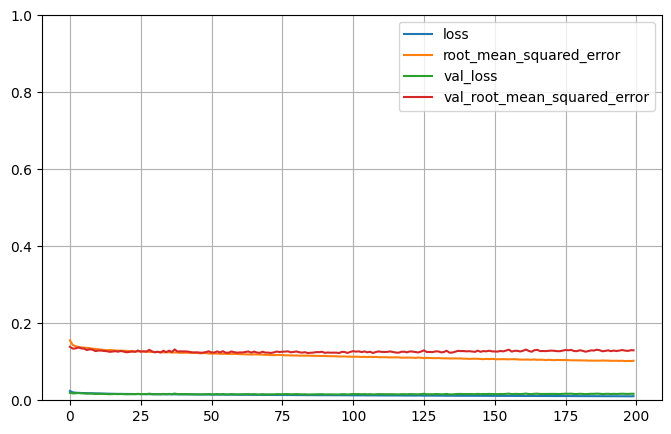

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [ ]:
scaler_datest_x = MinMaxScaler()
scaler_datest_y = MinMaxScaler()

datest_x = scaler_datest_x.fit_transform(datest[input_cols])
datest_y = scaler_datest_y.fit_transform(datest[[target_col]])

x_test_nn = datest_x
y_test_nn = datest_y

# pred_val = model.evaluate(x_test_nn, y_test_nn)
# pred_val
y_pred_nn = model.predict(x_test_nn)

medae_score = median_absolute_error(y_test_nn, y_pred_nn)
print(f'Median Score Error is: {medae_score}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Median Score Error is: 0.07973878351093709


In [ ]:
hrd_range = data['Hardness'].max() - data['Hardness'].min()
real_rmse = 0.0797 * hrd_range
real_rmse

0.7172999999999999

REMARKS: Final result shows that with Neural Network the MedAE scores 0.717, which is worse than `RandomForestRegressor`, and therefore we'll use `RandomForestRegressor` for this case.